# <center> **VISUALIZATION**

### **1) IMPORTS & LOADING DATASETS**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. AESTHETICS CONFIGURATION ---
# Digital Humanities Theme: Professional, clean, with cinema-appropriate colors
# "French Blue" for local content, "Hollywood Red" for English, "Gold" for highlights
custom_palette = ["#34495e", "#e74c3c", "#f1c40f", "#2ecc71"]
sns.set_theme(style="whitegrid", context="talk")
sns.set_palette(custom_palette)

# --- 2. LOAD DATA (Ensuring Types) ---
# Adjust paths if necessary based on your folder structure
movies = pd.read_parquet("../cleaned_data/movies.parquet")
ratings = pd.read_parquet("../cleaned_data/ratings.parquet")
# Assuming genres is the exploded bridge table
genres = pd.read_parquet("../cleaned_data/genres.parquet") 
# Assuming actors contains names and tconst
actors = pd.read_parquet("../cleaned_data/actors.parquet") 

# Merge ratings into movies for main analysis
df_main = pd.merge(movies, ratings, on='tconst', how='inner')

# Clean Runtime for plotting
df_main['runtimeMinutes'] = pd.to_numeric(df_main['runtimeMinutes'], errors='coerce')

### **2) The "Francophone Efficiency" (Quality vs. Quantity)**

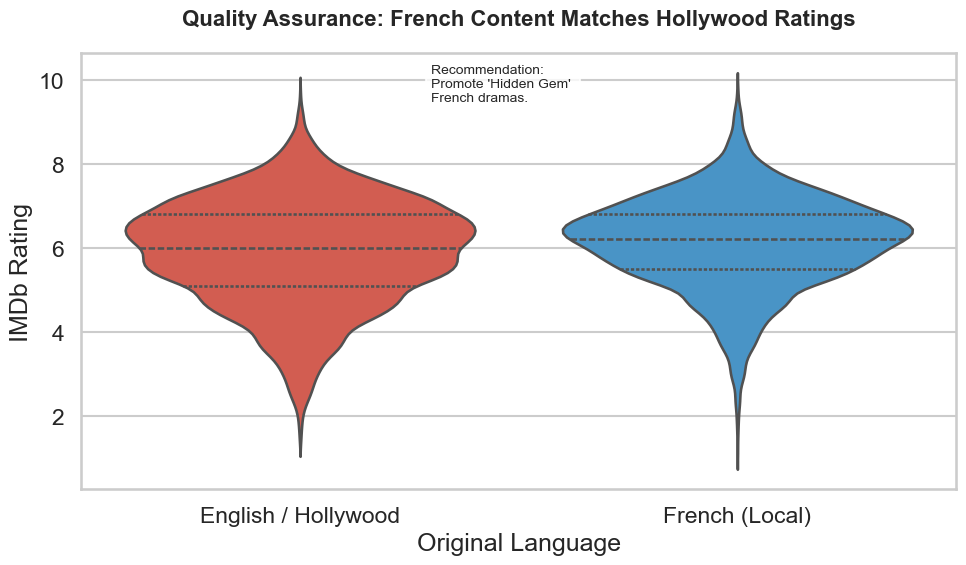

In [5]:
# --- VISUALIZATION 1: LANGUAGE vs RATING ---
plt.figure(figsize=(10, 6))

# Filter for main languages to avoid clutter
main_langs = df_main[df_main['detected_language'].isin(['fr', 'en'])]

# Create a Violin Plot (shows distribution better than boxplot)
sns.violinplot(
    data=main_langs,
    x='detected_language',
    y='averageRating',
    hue='detected_language',
    palette={'fr': '#3498db', 'en': '#e74c3c'}, # Blue for FR, Red for EN
    inner='quartile'
)

# Active Title
plt.title('Quality Assurance: French Content Matches Hollywood Ratings', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Original Language')
plt.ylabel('IMDb Rating')
plt.xticks([0, 1], ['English / Hollywood', 'French (Local)'])

# Annotation
plt.text(0.3, 9.5, "Recommendation: \nPromote 'Hidden Gem' \nFrench dramas.", 
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10)

plt.tight_layout()
plt.show()

### **3) The "Genre Pulse" (Bridge Table Analysis)**

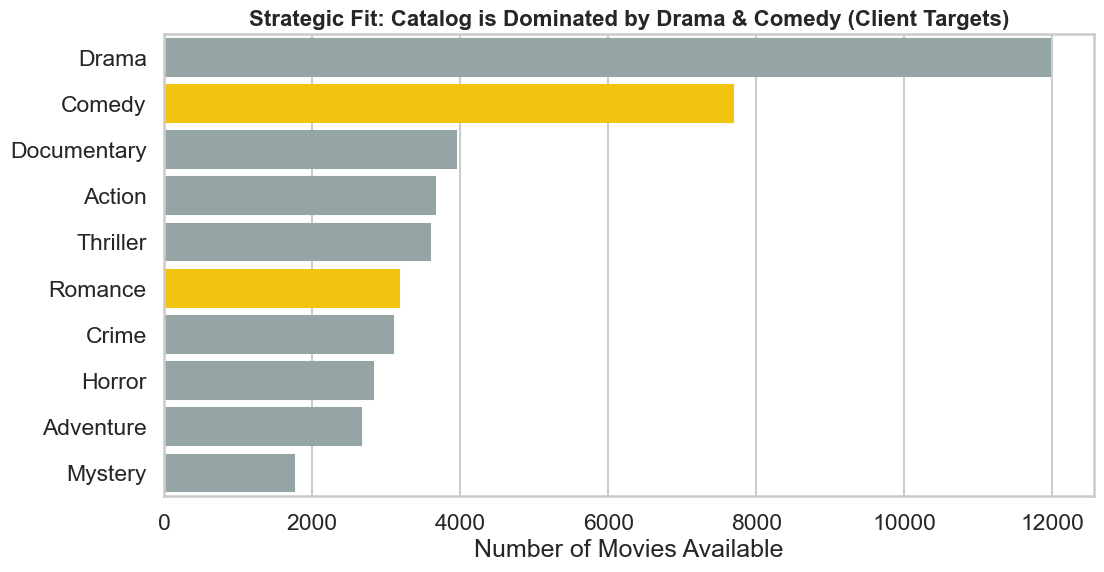

In [12]:
# --- VISUALIZATION 2: GENRE PREFERENCES ---
# Merge genres with ratings to get weighted popularity
genre_ratings = pd.merge(genres, ratings, on='tconst')

# Count Top 10 Genres
top_genres = genre_ratings['genres'].value_counts().head(10).index

plt.figure(figsize=(12, 6))
ax = sns.countplot(
    data=genre_ratings[genre_ratings['genres'].isin(top_genres)],
    y='genres',
    hue='genres',
    order=top_genres,
    palette='viridis'
)

# Highlight Drama and Comedy (The Client's Request)
# We loop through bars to change color of specific bars
for i, p in enumerate(ax.patches):
    if top_genres[i] in ['Drama', 'Comedy']:
        p.set_color('#f1c40f') # Gold color for target genres
    else:
        p.set_color('#95a5a6') # Grey for others

plt.title('Strategic Fit: Catalog is Dominated by Drama & Comedy (Client Targets)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Movies Available')
plt.ylabel('')
plt.show()

### **4) The "Nostalgia Curve" (Decade Analysis)**

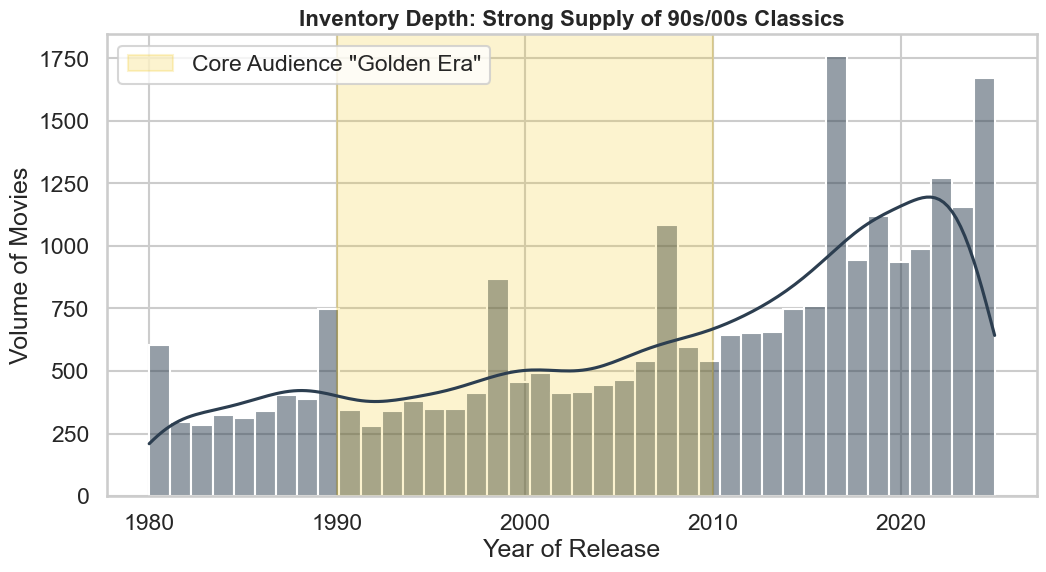

In [7]:
# --- VISUALIZATION 3: CONTENT ERA ---
# Ensure decade column exists
def get_decade(year):
    try:
        return int(year) // 10 * 10
    except:
        return 0

df_main['decade'] = df_main['startYear'].apply(get_decade)
df_filtered = df_main[df_main['decade'] >= 1980] # Focus on relevant era

plt.figure(figsize=(12, 6))
sns.histplot(data=df_filtered, x='startYear', bins=40, kde=True, color='#2c3e50')

# Highlight the "Nostalgia" era (1990-2010 for 45+ year olds)
plt.axvspan(1990, 2010, color='#f1c40f', alpha=0.2, label='Core Audience "Golden Era"')

plt.title('Inventory Depth: Strong Supply of 90s/00s Classics', fontsize=16, fontweight='bold')
plt.xlabel('Year of Release')
plt.ylabel('Volume of Movies')
plt.legend()
plt.show()

### **5) The "Star Power" (Digital Humanities Angle)**

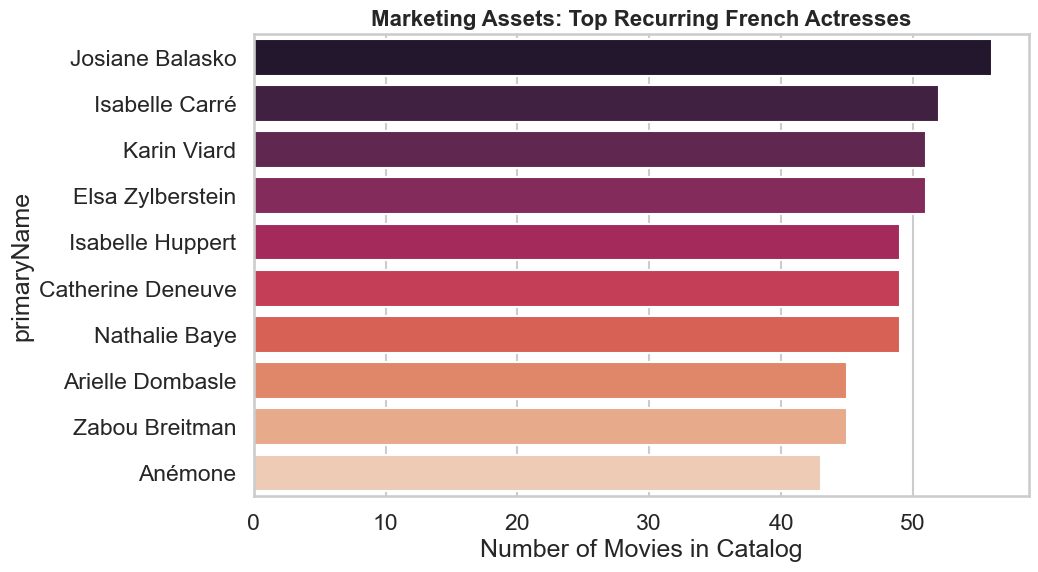

In [10]:
# --- VISUALIZATION 4: TOP FRENCH ACTRESSES ---
# 1. Filter for French Movies only
fr_movies = movies[movies['detected_language'] == 'fr']['tconst']

# 2. Filter Actors table for these movies AND category='actress'
fr_actresses = actors[
    (actors['tconst'].isin(fr_movies)) & 
    (actors['category'] == 'actress')
]

# 3. Count
top_stars = fr_actresses['primaryName'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_stars.values, 
            y=top_stars.index, 
            hue=top_stars.index,
            palette="rocket")

plt.title('Marketing Assets: Top Recurring French Actresses', fontsize=16, fontweight='bold')
plt.xlabel('Number of Movies in Catalog')
plt.show()